In [2]:
###############################################################################
# Cell 2: Imports and Basic Setup (same as before, just shortened for clarity)
###############################################################################
import math
import numpy as np
import torch
import torch.nn as nn
import requests
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [3]:
###############################################################################
# Cell 3: get_model_name (unchanged)
###############################################################################
def get_model_name(suite, size, deduped=False):
    """
    Return the HF model name for pythia or GPT-Neo, with deduped if relevant.
    """
    suite = suite.lower()
    size = size.lower()
    if suite == "pythia":
        if size == "70m":
            return f"EleutherAI/pythia-70m{'-deduped' if deduped else ''}"
        elif size == "160m":
            return f"EleutherAI/pythia-160m{'-deduped' if deduped else ''}"
        elif size == "1.4b":
            return f"EleutherAI/pythia-1.4b{'-deduped' if deduped else ''}"
        elif size == "2.8b":
            return f"EleutherAI/pythia-2.8b{'-deduped' if deduped else ''}"
        elif size == "6.9b":
            return f"EleutherAI/pythia-6.9b{'-deduped' if deduped else ''}"
        elif size == "12b":
            return f"EleutherAI/pythia-12b{'-deduped' if deduped else ''}"
        else:
            raise ValueError(f"Unsupported pythia size: {size}")
    elif suite=="gpt-neo":
        if size=="125m":
            return "EleutherAI/gpt-neo-125M"
        elif size=="1.3b":
            return "EleutherAI/gpt-neo-1.3B"
        elif size=="2.7b":
            return "EleutherAI/gpt-neo-2.7B"
        else:
            raise ValueError(f"Unsupported gpt-neo size: {size}")
    else:
        raise ValueError(f"Unknown suite: {suite}")

In [4]:
###############################################################################
# Cell 4 (UPDATED): Next-token loss + signals
###############################################################################

import math
import numpy as np
import torch
import torch.nn as nn

@torch.no_grad()
def compute_next_token_losses_batch(
    texts,
    model,
    tokenizer,
    device="cuda",
    max_length=1024
):
    """
    Returns a list of per-token losses for each text in 'texts'.
    """
    if len(texts)==0:
        return []

    enc = tokenizer(
        texts,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=max_length
    )
    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)

    outputs = model(input_ids, labels=input_ids, attention_mask=attention_mask)
    logits = outputs.logits  # shape: [batch_size, seq_len, vocab_size]

    # shift for next-token
    logits = logits[:, :-1, :]
    target = input_ids[:, 1:]
    mask   = attention_mask[:, 1:]

    bsz, seq_len_minus1, vocab_size = logits.shape
    logits_flat = logits.reshape(-1, vocab_size)
    target_flat = target.reshape(-1)

    loss_fct = nn.CrossEntropyLoss(reduction='none')
    token_losses_flat = loss_fct(logits_flat, target_flat)
    token_losses = token_losses_flat.view(bsz, seq_len_minus1)

    loss_seq_list = []
    for i in range(bsz):
        valid_len = int(mask[i].sum().item())
        # If valid_len=0, we have an empty sequence
        seq_losses = token_losses[i, :valid_len].tolist()
        loss_seq_list.append(seq_losses)

    return loss_seq_list

def replicate_if_short(seq, desired_len):
    out = list(seq)
    while len(out) < desired_len and len(out)>0:
        out += seq
    return out

def slope_signal(loss_seq, Tprime=200):
    arr = list(loss_seq)
    if len(arr)==0:
        return 0.0
    if len(arr)<Tprime:
        arr = replicate_if_short(arr, Tprime)
    arr = arr[:Tprime]
    if len(arr)<2:
        return 0.0
    x_vals = np.arange(len(arr))
    y_vals = np.array(arr)
    mean_x = x_vals.mean()
    mean_y = y_vals.mean()
    numerator   = np.sum((x_vals - mean_x)*(y_vals - mean_y))
    denominator = np.sum((x_vals - mean_x)**2)
    if abs(denominator)<1e-12:
        return 0.0
    return float(numerator/denominator)

def approximate_entropy(loss_seq, Tprime=200, m=8, r=0.8):
    arr = list(loss_seq)
    if len(arr)==0:
        return 0.0
    if len(arr)<Tprime:
        arr = replicate_if_short(arr, Tprime)
    arr = arr[:Tprime]

    vals = np.array(arr)
    n = len(vals)
    if n < (m+1):
        return 0.0

    def _maxdist(a,b):
        return np.max(np.abs(a-b))

    x_m = [vals[i:i+m] for i in range(n-m+1)]
    c=[]
    for i in range(len(x_m)):
        cnt=0
        for j in range(len(x_m)):
            if _maxdist(x_m[i], x_m[j])<=r:
                cnt+=1
        c.append(cnt/len(x_m))
    phi_m = np.mean(np.log(np.array(c)+1e-9))

    if n < (m+1+1):
        return 0.0
    x_m2 = [vals[i:i+m+1] for i in range(n-(m+1)+1)]
    c2=[]
    for i in range(len(x_m2)):
        cnt=0
        for j in range(len(x_m2)):
            if _maxdist(x_m2[i], x_m2[j])<=r:
                cnt+=1
        c2.append(cnt/len(x_m2))
    phi_m2 = np.mean(np.log(np.array(c2)+1e-9))
    return float(phi_m - phi_m2)

def token_diversity(text, tokenizer):
    tokens = tokenizer.tokenize(text)
    if len(tokens)==0:
        return 0.0
    return len(set(tokens))/len(tokens)

def gather_signals_for_batch(
    texts, model, tokenizer, device="cuda", max_length=1024,
    store_full_sequences=True  # <--- CHANGED: optional
):
    """
    Returns a list of dicts, one per text.

    For each text, we do 3 forward passes (orig, rep2, rep3) and compute
    membership signals (cut_200, slope, LZ, etc.).

    If store_full_sequences=True, we also store the entire next-token
    loss sequences in the dictionary under keys "loss_seq_orig",
    "loss_seq_rep2", "loss_seq_rep3". These are large lists of floats
    that are *not numeric scalars*, so Edgington or logistic must skip them.
    """
    rep2_texts = [t + " " + t for t in texts]
    rep3_texts = [t + " " + t + " " + t for t in texts]

    orig_lossseqs = compute_next_token_losses_batch(texts,      model, tokenizer, device, max_length)
    rep2_lossseqs = compute_next_token_losses_batch(rep2_texts, model, tokenizer, device, max_length)
    rep3_lossseqs = compute_next_token_losses_batch(rep3_texts, model, tokenizer, device, max_length)

    def cutoff_loss(loss_seq, Tprime=None):
        if len(loss_seq)==0:
            return float('inf')
        if Tprime is None or Tprime>len(loss_seq):
            return float(np.mean(loss_seq))
        return float(np.mean(loss_seq[:Tprime]))

    results = []
    for i, original_text in enumerate(texts):
        seq_orig = orig_lossseqs[i]
        seq_rep2 = rep2_lossseqs[i]
        seq_rep3 = rep3_lossseqs[i]

        cut_all  = cutoff_loss(seq_orig, None)
        cut_200  = cutoff_loss(seq_orig, 200)
        cut_300  = cutoff_loss(seq_orig, 300)
        rep2_all = cutoff_loss(seq_rep2, None)
        rep2_200 = cutoff_loss(seq_rep2, 200)
        rep2_300 = cutoff_loss(seq_rep2, 300)
        rep3_all = cutoff_loss(seq_rep3, None)
        rep3_200 = cutoff_loss(seq_rep3, 200)
        rep3_300 = cutoff_loss(seq_rep3, 300)

        sdict = {}
        sdict["cut_all"]  = cut_all
        sdict["cut_200"]  = cut_200
        sdict["cut_300"]  = cut_300
        sdict["cut_all_rep1_diff"]  = cut_all - rep2_all
        sdict["cut_all_rep2_diff"]  = cut_all - rep3_all
        sdict["cut_200_rep1_diff"]  = cut_200 - rep2_200
        sdict["cut_200_rep2_diff"]  = cut_200 - rep3_200
        sdict["cut_300_rep1_diff"]  = cut_300 - rep2_300
        sdict["cut_300_rep2_diff"]  = cut_300 - rep3_300

        div = token_diversity(original_text, tokenizer)
        def safe_div(x, d):
            return x/d if d>1e-9 else float('inf')

        sdict["cal_all"] = safe_div(cut_all, div)
        sdict["cal_200"] = safe_div(cut_200, div)
        sdict["cal_300"] = safe_div(cut_300, div)

        sdict["cal_all_rep1_diff"]  = sdict["cal_all"] - safe_div(rep2_all, div)
        sdict["cal_all_rep2_diff"]  = sdict["cal_all"] - safe_div(rep3_all, div)
        sdict["cal_200_rep1_diff"]  = sdict["cal_200"] - safe_div(rep2_200, div)
        sdict["cal_200_rep2_diff"]  = sdict["cal_200"] - safe_div(rep3_200, div)
        sdict["cal_300_rep1_diff"]  = sdict["cal_300"] - safe_div(rep2_300, div)
        sdict["cal_300_rep2_diff"]  = sdict["cal_300"] - safe_div(rep3_300, div)

        for Tprime in [600,800,1000]:
            sdict[f"slope_{Tprime}"] = slope_signal(seq_orig, Tprime)
            sdict[f"apen_{Tprime}"]  = approximate_entropy(seq_orig, Tprime, 8, 0.8)

        import math
        def safe_exp(v):
            return math.exp(v) if v!=float('inf') else float('inf')

        ppl_all   = safe_exp(cut_all)
        ppl_200   = safe_exp(cut_200)
        ppl_300   = safe_exp(cut_300)
        rep2_ppl_all = safe_exp(rep2_all)
        rep2_ppl_200 = safe_exp(rep2_200)
        rep2_ppl_300 = safe_exp(rep2_300)
        rep3_ppl_all = safe_exp(rep3_all)
        rep3_ppl_200 = safe_exp(rep3_200)
        rep3_ppl_300 = safe_exp(rep3_300)

        sdict["ppl_all"] = ppl_all
        sdict["ppl_200"] = ppl_200
        sdict["ppl_300"] = ppl_300
        sdict["ppl_all_rep1_diff"]  = ppl_all - rep2_ppl_all
        sdict["ppl_all_rep2_diff"]  = ppl_all - rep3_ppl_all
        sdict["ppl_200_rep1_diff"]  = ppl_200 - rep2_ppl_200
        sdict["ppl_200_rep2_diff"]  = ppl_200 - rep3_ppl_200
        sdict["ppl_300_rep1_diff"]  = ppl_300 - rep2_ppl_300
        sdict["ppl_300_rep2_diff"]  = ppl_300 - rep3_ppl_300

        calppl_all  = safe_div(ppl_all,  div)
        calppl_200  = safe_div(ppl_200,  div)
        calppl_300  = safe_div(ppl_300,  div)
        rep2_calppl_all = safe_div(rep2_ppl_all, div)
        rep3_calppl_all = safe_div(rep3_ppl_all, div)
        rep2_calppl_200 = safe_div(rep2_ppl_200, div)
        rep3_calppl_200 = safe_div(rep3_ppl_200, div)
        rep2_calppl_300 = safe_div(rep2_ppl_300, div)
        rep3_calppl_300 = safe_div(rep3_ppl_300, div)

        sdict["calppl_all"] = calppl_all
        sdict["calppl_200"] = calppl_200
        sdict["calppl_300"] = calppl_300
        sdict["calppl_all_rep1_diff"] = calppl_all - rep2_calppl_all
        sdict["calppl_all_rep2_diff"] = calppl_all - rep3_calppl_all
        sdict["calppl_200_rep1_diff"] = calppl_200 - rep2_calppl_200
        sdict["calppl_200_rep2_diff"] = calppl_200 - rep3_calppl_200
        sdict["calppl_300_rep1_diff"] = calppl_300 - rep2_calppl_300
        sdict["calppl_300_rep2_diff"] = calppl_300 - rep3_calppl_300

        def count_below_threshold(seq, threshold, Tprime=200):
            arr = seq[:Tprime] if len(seq)>=Tprime else seq
            if len(arr)==0:
                return 0.0
            return sum(1 for x in arr if x<=threshold)/len(arr)

        sdict["cb_const1"] = count_below_threshold(seq_orig, 1.0, 200)
        sdict["cb_const2"] = count_below_threshold(seq_orig, 2.0, 200)
        sdict["cb_const3"] = count_below_threshold(seq_orig, 3.0, 200)

        def count_below_mean(seq, Tprime=200):
            arr = seq[:Tprime] if len(seq)>=Tprime else seq
            if len(arr)==0:
                return 0.0
            avgv = np.mean(arr)
            return sum(1 for x in arr if x<=avgv)/len(arr)
        sdict["cb_mean"] = count_below_mean(seq_orig, 200)

        def count_below_prev_mean(seq, Tprime=200):
            arr = seq[:Tprime] if len(seq)>=Tprime else seq
            if len(arr)<2:
                return 0.0
            ccount=0
            running_sum=0.0
            for idx,val in enumerate(arr):
                if idx==0:
                    running_sum += val
                    continue
                pm = running_sum/idx
                if val<=pm:
                    ccount+=1
                running_sum += val
            total = len(arr)-1
            return ccount/total if total>0 else 0.0

        sdict["cb_prev_mean"] = count_below_prev_mean(seq_orig, 200)

        def lempel_ziv_complexity(seq, Tprime=200, bins=3):
            arr = seq[:Tprime] if len(seq)>=Tprime else seq
            if len(arr)==0:
                return 0.0
            arr = np.array(arr)
            mn, mx = arr.min(), arr.max()
            if abs(mx - mn)<1e-12:
                return 1.0
            bin_edges = np.linspace(mn, mx+1e-9, bins)
            codes = np.digitize(arr, bin_edges)
            s = "".join(chr(int(c)+65) for c in codes)
            i=0
            c=1
            length=len(s)
            while i<length-1:
                sub = s[i:i+1]
                while (s[i:i+len(sub)] in s[:i]) and (i+len(sub)<length):
                    sub += s[i+len(sub)]
                i+=len(sub)
                c+=1
            return float(c)

        for nbins in [3,4,5]:
            sdict[f"lz_bins{nbins}"] = lempel_ziv_complexity(seq_orig, 200, nbins)

        # CHANGED: store the entire loss sequences if store_full_sequences=True
        if store_full_sequences:
            sdict["loss_seq_orig"] = seq_orig
            sdict["loss_seq_rep2"] = seq_rep2
            sdict["loss_seq_rep3"] = seq_rep3

        results.append(sdict)

    return results

def gather_signals_for_dataset(
    texts,
    model,
    tokenizer,
    device="cuda",
    max_length=1024,
    batch_size=8
):
    """
    Single pass over 'texts' in given batch_size. We'll store all final signal
    dicts in 'all_sdicts' and return them.

    This is typically what you'd call once for members, once for nonmembers.
    """
    from tqdm import tqdm
    all_sdicts = []
    print(f"--> Starting signal extraction for {len(texts)} texts, in batches of {batch_size}")
    for start_i in tqdm(range(0, len(texts), batch_size), desc="Gathering signals"):
        end_i = start_i + batch_size
        batch_texts = texts[start_i:end_i]
        # store_full_sequences = True by default in gather_signals_for_batch
        batch_sigs = gather_signals_for_batch(
            batch_texts, model, tokenizer, device, max_length, store_full_sequences=True
        )
        all_sdicts.extend(batch_sigs)
    print("--> Finished signal extraction.")
    return all_sdicts


In [5]:
###############################################################################
# Cell 6 (UPDATED to handle groupwise final dimension & fix the last plot)
###############################################################################
import bisect
from collections import defaultdict
import numpy as np

def edgington_fit(nonmember_sdicts):
    ref_dict = defaultdict(list)
    print("\n[Edgington Fit] Building reference distribution ...")
    for sdict in nonmember_sdicts:
        for k,v in sdict.items():
            if isinstance(v, (int, float)):
                ref_dict[k].append(v)
    for k in ref_dict.keys():
        ref_dict[k] = np.sort(ref_dict[k])
    return ref_dict

def edgington_score_batch(sdicts, ref_dict):
    print("[Edgington Score] Summing p-values for test data ...")
    results = []
    for sdict in sdicts:
        total = 0.0
        for k,v in sdict.items():
            arr = ref_dict.get(k, None)
            if arr is None or len(arr)==0:
                continue
            idx = bisect.bisect_right(arr, v)
            frac = idx / len(arr)
            total += frac
        results.append(total)
    return results

def logistic_fit(member_sdicts, nonmember_sdicts):
    """
    Return: (clf, all_keys, group2pca, group_tags, final_feature_groups)
    """
    print("\n[Logistic Fit] Gathering numeric features ...")
    Xdicts = []
    Y = []
    for d in member_sdicts:
        Xdicts.append(d)
        Y.append(1)
    for d in nonmember_sdicts:
        Xdicts.append(d)
        Y.append(0)

    # collect numeric keys
    all_numeric_keys = set()
    for d in Xdicts:
        for k,v in d.items():
            if isinstance(v,(int,float)):
                all_numeric_keys.add(k)
    all_keys = sorted(list(all_numeric_keys))

    # Build Xmat
    Xmat = []
    for rowdict in Xdicts:
        rowvals = []
        for k in all_keys:
            v = rowdict.get(k, 0.0)
            if not isinstance(v,(int,float)):
                v=0.0
            rowvals.append(v)
        Xmat.append(rowvals)
    Xmat = np.array(Xmat, dtype=float)
    Y = np.array(Y, dtype=int)

    def group_of(k):
        if k.startswith("cut"):
            return "cut"
        elif k.startswith("calppl"):
            return "calppl"
        elif k.startswith("ppl"):
            return "ppl"
        elif k.startswith("cal_"):
            return "cal"
        elif k.startswith("cb_const"):
            return "cbconst"
        elif k.startswith("cb_mean"):
            return "cbmean"
        elif k.startswith("cb_prev_mean"):
            return "cbpm"
        elif k.startswith("lz_bins"):
            return "lz"
        elif k.startswith("slope"):
            return "slope"
        elif k.startswith("apen"):
            return "apen"
        else:
            return "misc"

    group_tags = {}
    for k in all_keys:
        group_tags[k] = group_of(k)

    group2cols = defaultdict(list)
    for i,k in enumerate(all_keys):
        grp = group_tags[k]
        group2cols[grp].append(i)

    from sklearn.decomposition import PCA
    pca_components_per_group = 2

    newXlist = [[] for _ in range(len(Xmat))]
    group2pca = {}
    final_feature_groups = []  # each final dimension's group

    print("[Logistic Fit] Doing groupwise PCA ...")
    for grp, idxs in group2cols.items():
        subX = Xmat[:, idxs]
        if subX.shape[1] == 1:
            # no PCA
            for row_i in range(len(Xmat)):
                newXlist[row_i].append(subX[row_i,0])
            group2pca[grp] = None
            final_feature_groups.append(grp)  # 1 dimension => 1 final dim
        else:
            pca = PCA(n_components=min(pca_components_per_group, subX.shape[1]))
            pca.fit(subX)
            trans = pca.transform(subX)
            group2pca[grp] = pca
            n_dim = trans.shape[1]
            for dim_i in range(n_dim):
                final_feature_groups.append(grp)
            for row_i in range(len(Xmat)):
                newXlist[row_i].extend(list(trans[row_i]))

    finalX = np.array(newXlist, dtype=float)

    from sklearn.linear_model import LogisticRegression
    print("[Logistic Fit] Fitting logistic regression ...")
    clf = LogisticRegression(solver="lbfgs", max_iter=1000)
    clf.fit(finalX, Y)
    return clf, all_keys, group2pca, group_tags, final_feature_groups


def logistic_score_batch(sdicts, clf, all_keys, group2pca, group_tags):
    from collections import defaultdict
    results = []
    for sdict in sdicts:
        row = []
        for k in all_keys:
            v = sdict.get(k,0.0)
            if not isinstance(v,(int,float)):
                v=0.0
            row.append(v)
        row = np.array(row, dtype=float).reshape(1,-1)

        subgroups = defaultdict(list)
        for i,k in enumerate(all_keys):
            grp = group_tags[k]
            subgroups[grp].append(row[0,i])

        newrow = []
        for grp, pca in group2pca.items():
            arr = np.array(subgroups[grp]).reshape(1,-1)
            if pca is None:
                newrow.extend(list(arr[0]))
            else:
                out = pca.transform(arr)
                newrow.extend(list(out[0]))
        newrow = np.array(newrow).reshape(1,-1)

        prob = clf.predict_proba(newrow)[0,1]
        score = -prob
        results.append(score)
    return results


In [6]:
###############################################################################
# Cell 7: compute_metrics_and_show
###############################################################################
from sklearn.metrics import roc_auc_score, roc_curve

def compute_metrics_and_show(mem_scores, nm_scores, show_plot=True):
    import matplotlib.pyplot as plt
    import numpy as np

    ytrue = np.array([1]*len(mem_scores) + [0]*len(nm_scores))
    yscore= np.concatenate([mem_scores, nm_scores], axis=0)
    yscore_invert = -yscore  # since we said "smaller => membership"

    auc_val = roc_auc_score(ytrue, yscore_invert)
    fpr, tpr, thresholds = roc_curve(ytrue, yscore_invert)
    idx = np.argmin(np.abs(fpr - 0.01))
    tpr_001fpr = tpr[idx]

    print(f"AUC = {auc_val:.4f}")
    print(f"TPR@1%FPR = {tpr_001fpr*100:.2f}%")

    if show_plot:
        plt.figure()
        plt.plot(fpr, tpr, label=f"ROC (AUC={auc_val:.4f})")
        plt.plot([0,1],[0,1],'--')
        plt.xlim([0,1])
        plt.ylim([0,1])
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve (inverted membership scores)")
        plt.legend()
        plt.show()

    return auc_val, tpr_001fpr


In [10]:
###############################################################################
# Cell 8 (UPDATED): Minimal demonstration with MIMIR + saving to CSV
###############################################################################
import os
import pandas as pd
import json

# Example with small data
domain_name = "arxiv"
split_name  = "ngram_7_0.2"
num_samples = 1000

my_hf_token = "[my code]"  # your HF token
print(f"Loading MIMIR dataset '{domain_name}' with split '{split_name}' from HF ...")

ds = load_dataset(
    "iamgroot42/mimir",
    domain_name,
    split=split_name,
    token=my_hf_token
)
print("MIMIR dataset structure:", ds)
print("Sample fields from the dataset:\n", ds[0])

all_members    = ds["member"][:num_samples]
all_nonmembers = ds["nonmember"][:num_samples]
print(f"Final: {len(all_members)} members, {len(all_nonmembers)} nonmembers")

suite = "pythia"
size  = "70m"
dedup = False

model_name = get_model_name(suite, size, dedup)
print(f"Loading model: {model_name}")

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.add_special_tokens({'pad_token': '[PAD]'})

model = AutoModelForCausalLM.from_pretrained(model_name)
model.to(device)
model.eval()

# 1) Extract signals ONCE per group, possibly storing full sequences
print("\nGathering signals for members ...")
mem_sdicts = gather_signals_for_dataset(all_members, model, tokenizer, device,
                                        max_length=1024, batch_size=2)
print("Done. Gathering signals for nonmembers ...")
nm_sdicts = gather_signals_for_dataset(all_nonmembers, model, tokenizer, device,
                                       max_length=1024, batch_size=2)
print("Done with all signal extractions!")

# 2) Edgington Approach
ref_dict = edgington_fit(nm_sdicts)
mem_scores_edg = edgington_score_batch(mem_sdicts, ref_dict)
nm_scores_edg  = edgington_score_batch(nm_sdicts,  ref_dict)

# 3) Logistic+PCA approach
clf, all_keys, group2pca, group_tags, final_feature_groups = logistic_fit(mem_sdicts, nm_sdicts)
mem_scores_log = logistic_score_batch(mem_sdicts, clf, all_keys, group2pca, group_tags)
nm_scores_log  = logistic_score_batch(nm_sdicts, clf, all_keys, group2pca, group_tags)

# Evaluate & print
print("\n=== Edgington Attack ===")
auc_edg, tpr01_edg = compute_metrics_and_show(mem_scores_edg, nm_scores_edg, show_plot=False)
print("=== Logistic+PCA Attack ===")
auc_log, tpr01_log = compute_metrics_and_show(mem_scores_log, nm_scores_log, show_plot=False)

# Optionally compute membership scores for each individual signal
def get_single_signal_scores(sdicts, signal_key, invert=True):
    """
    Return membership scores for a single sdict-based signal. 
    By convention, smaller => membership => invert=True.
    """
    vals = [d[signal_key] for d in sdicts]
    # typically, we just return them, and interpret smaller as membership
    return vals

# Example usage
mem_cut200_scores = get_single_signal_scores(mem_sdicts, "cut_200", invert=True)
nm_cut200_scores  = get_single_signal_scores(nm_sdicts, "cut_200", invert=True)

# 4) Build a DataFrame of per-text results
rows = []
for i, sdict in enumerate(mem_sdicts):
    row = {}
    row["text_index"] = i
    row["membership_label"] = 1
    # store aggregated signals (just a subset for demonstration)
    row["cut_200"] = sdict["cut_200"]
    row["cal_200"] = sdict["cal_200"]
    row["edgington_score"] = mem_scores_edg[i]
    row["logistic_score"]  = mem_scores_log[i]
    # store the entire original token-loss sequence if needed
    # This might be large in CSV but we show how to do it:
    row["loss_seq_orig"] = sdict.get("loss_seq_orig", None)
    rows.append(row)

offset = len(mem_sdicts)
for j, sdict in enumerate(nm_sdicts):
    row = {}
    row["text_index"] = offset + j
    row["membership_label"] = 0
    row["cut_200"] = sdict["cut_200"]
    row["cal_200"] = sdict["cal_200"]
    row["edgington_score"] = nm_scores_edg[j]
    row["logistic_score"]  = nm_scores_log[j]
    row["loss_seq_orig"] = sdict.get("loss_seq_orig", None)
    rows.append(row)

df_run = pd.DataFrame(rows)

# 5) Save to CSV
outdir = "results"
os.makedirs(outdir, exist_ok=True)
filename_pertext = f"results_{domain_name}_{suite}{size}.csv"
outpath = os.path.join(outdir, filename_pertext)
df_run.to_csv(outpath, index=False)
print(f"Saved per-text results to {outpath}")

# 6) Save summary metrics
summary_data = {
    "model_suite": suite,
    "model_size": size,
    "domain": domain_name,
    "attack_edgington_auc": auc_edg,
    "attack_edgington_tpr01": tpr01_edg,
    "attack_logistic_auc": auc_log,
    "attack_logistic_tpr01": tpr01_log,
}
filename_summary = f"summary_{domain_name}_{suite}{size}.json"
outpath_summary = os.path.join(outdir, filename_summary)
with open(outpath_summary, "w") as f:
    json.dump(summary_data, f, indent=2)
print(f"Saved summary metrics to {outpath_summary}")

print("\nCell 8 done!")


Loading MIMIR dataset 'arxiv' with split 'ngram_7_0.2' from HF ...


Using the latest cached version of the module from /home/edgelab/.cache/huggingface/modules/datasets_modules/datasets/iamgroot42--mimir/99dd53483f73e1949849b6202ab5c394203fb920504c1307e17105565ac9e33b (last modified on Mon Apr  7 13:55:00 2025) since it couldn't be found locally at iamgroot42/mimir, or remotely on the Hugging Face Hub.


MIMIR dataset structure: Dataset({
    features: ['member', 'nonmember', 'member_neighbors', 'nonmember_neighbors'],
    num_rows: 500
})
Sample fields from the dataset:
 {'member': "---\nabstract: 'In this paper we extend the deterministic sublinear FFT algorithm for fast reconstruction of $M$-sparse vectors of length $N= 2^J$ considered in [@PWC18]. Our numerical experiences show that our modification has a huge impact on the stability of the algorithm, while the runtime of the algorithm is still ${\\mathcal O}(M^2 \\, \\log N)$.'\nbibliography:\n- 'bibliography.bib'\n---\n\nGerlind Plonka and Therese von Wulffen\n\nIntroduction\n============\n\nSparse FFT methods can be used in many different applications, where it is a priori known that the resulting signal in time/space or frequency domain is sparse. Such algorithms have earned a considerable interest within the last years.\n\nMany deterministic sparse FFT algorithms are based on combinatorial approaches or phase shift, see e.g.\x

Gathering signals: 100%|██████████| 250/250 [2:38:01<00:00, 37.92s/it]  


--> Finished signal extraction.
Done. Gathering signals for nonmembers ...
--> Starting signal extraction for 500 texts, in batches of 2


Gathering signals: 100%|██████████| 250/250 [2:52:32<00:00, 41.41s/it]  


--> Finished signal extraction.
Done with all signal extractions!

[Edgington Fit] Building reference distribution ...
[Edgington Score] Summing p-values for test data ...
[Edgington Score] Summing p-values for test data ...

[Logistic Fit] Gathering numeric features ...
[Logistic Fit] Doing groupwise PCA ...
[Logistic Fit] Fitting logistic regression ...

=== Edgington Attack ===
AUC = 0.7268
TPR@1%FPR = 2.40%
=== Logistic+PCA Attack ===
AUC = 0.7927
TPR@1%FPR = 19.60%
Saved per-text results to results/results_arxiv_pythia70m.csv
Saved summary metrics to results/summary_arxiv_pythia70m.json

Cell 8 done!


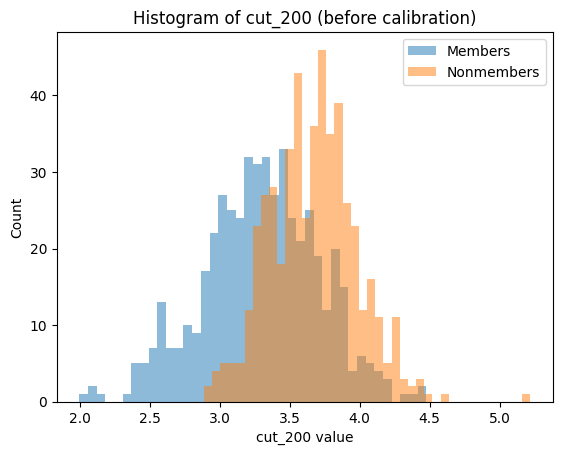

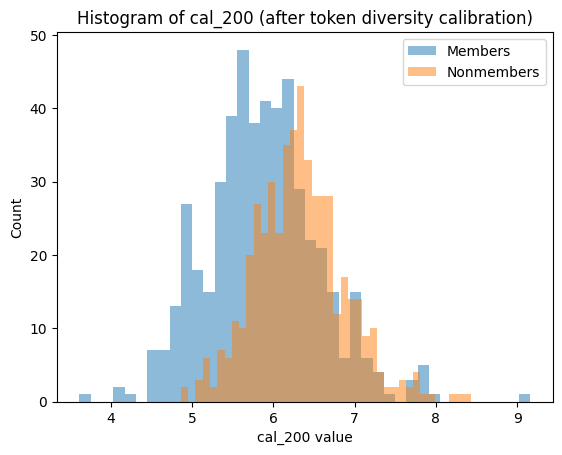

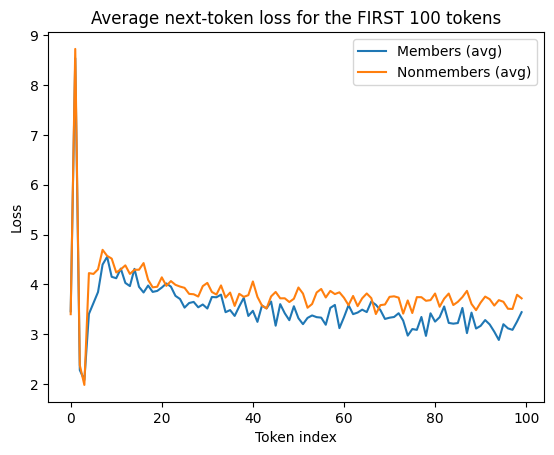

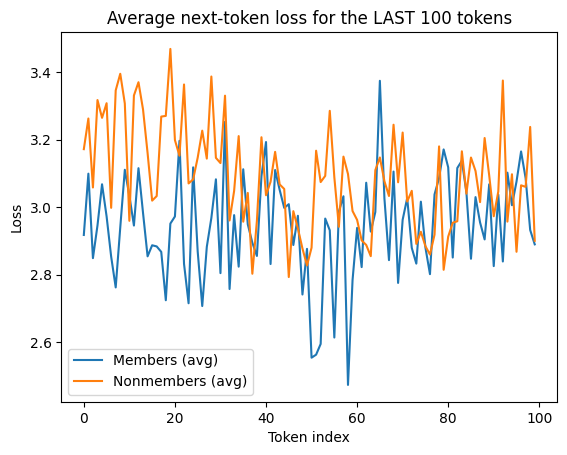

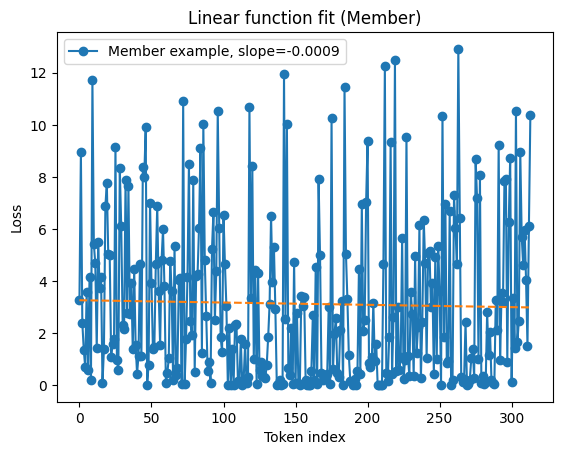

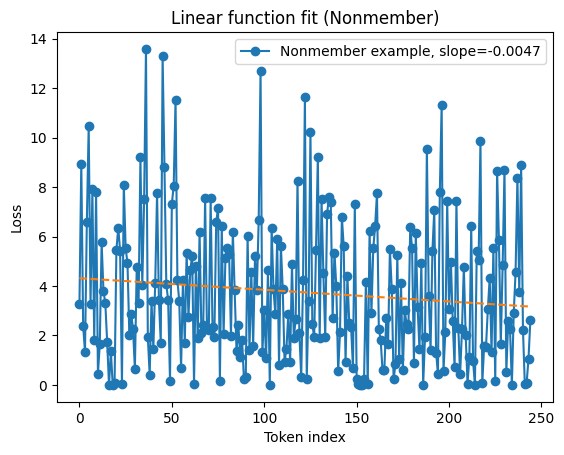

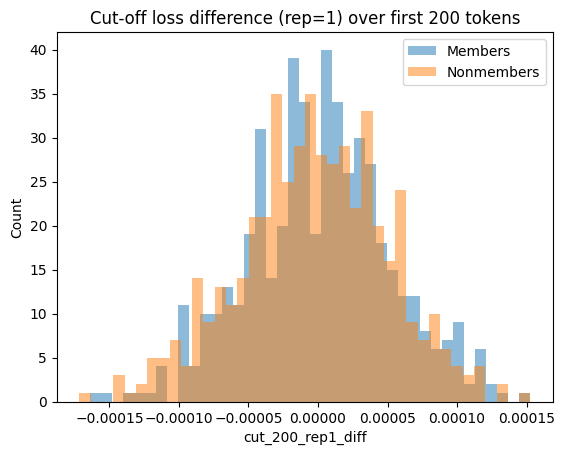

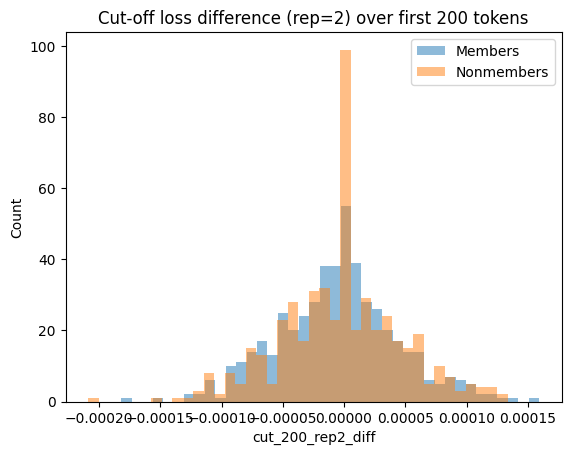

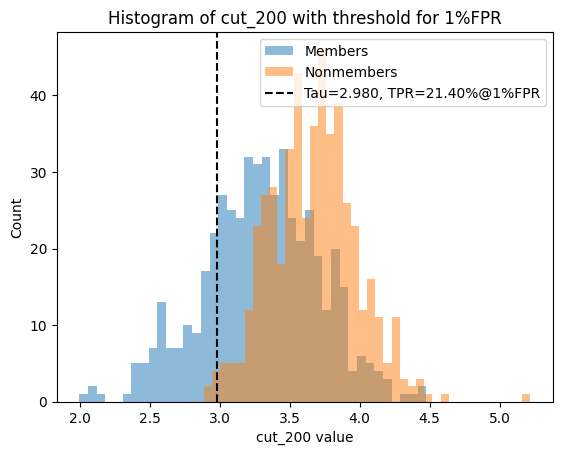

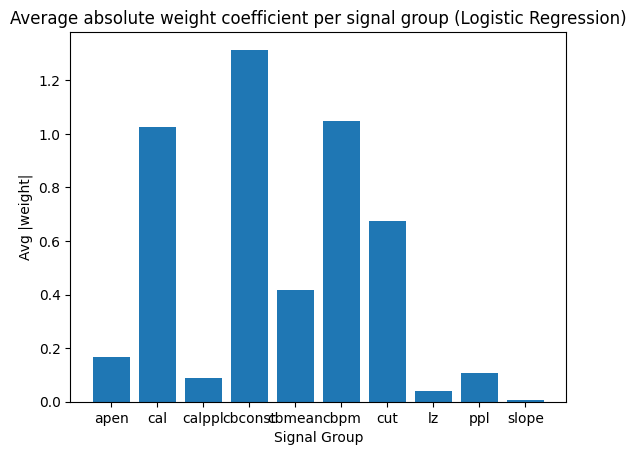

Cell 9 done!


In [11]:
###############################################################################
# Cell 9: Single-run Figures
###############################################################################
import matplotlib.pyplot as plt
import numpy as np
import random
from numpy.polynomial import Polynomial

# 1) TOKEN DIVERSITY CALIBRATION
mem_cut200 = [d["cut_200"] for d in mem_sdicts]
nm_cut200  = [d["cut_200"] for d in nm_sdicts]
mem_cal200 = [d["cal_200"] for d in mem_sdicts]
nm_cal200  = [d["cal_200"] for d in nm_sdicts]

plt.figure()
plt.hist(mem_cut200, bins=40, alpha=0.5, label="Members")
plt.hist(nm_cut200, bins=40, alpha=0.5, label="Nonmembers")
plt.title("Histogram of cut_200 (before calibration)")
plt.xlabel("cut_200 value")
plt.ylabel("Count")
plt.legend()
plt.show()

plt.figure()
plt.hist(mem_cal200, bins=40, alpha=0.5, label="Members")
plt.hist(nm_cal200, bins=40, alpha=0.5, label="Nonmembers")
plt.title("Histogram of cal_200 (after token diversity calibration)")
plt.xlabel("cal_200 value")
plt.ylabel("Count")
plt.legend()
plt.show()

# 2) AVERAGE NEXT-TOKEN LOSS: FIRST 100 vs LAST 100

def compute_avg_loss_by_index(sdicts, first_or_last=100):
    # gather all sequences
    all_seqs = [d["loss_seq_orig"] for d in sdicts]
    maxlen = max(len(s) for s in all_seqs) if len(all_seqs)>0 else 0

    if first_or_last>0:
        L = min(first_or_last, maxlen)
        arr = []
        for seq in all_seqs:
            if len(seq)<L:
                padded = seq + [np.nan]*(L-len(seq))
                arr.append(padded)
            else:
                arr.append(seq[:L])
        arr = np.array(arr, dtype=float)
        avg_loss = np.nanmean(arr, axis=0)
        return avg_loss
    else:
        L = min(abs(first_or_last), maxlen)
        arr = []
        for seq in all_seqs:
            if len(seq)<L:
                needed = L - len(seq)
                padded = [np.nan]*needed + seq
                arr.append(padded)
            else:
                arr.append(seq[-L:])
        arr = np.array(arr, dtype=float)
        avg_loss = np.nanmean(arr, axis=0)
        return avg_loss

mem_first100 = compute_avg_loss_by_index(mem_sdicts, first_or_last=100)
nm_first100  = compute_avg_loss_by_index(nm_sdicts, first_or_last=100)

plt.figure()
plt.plot(range(len(mem_first100)), mem_first100, label="Members (avg)")
plt.plot(range(len(nm_first100)), nm_first100, label="Nonmembers (avg)")
plt.title("Average next-token loss for the FIRST 100 tokens")
plt.xlabel("Token index")
plt.ylabel("Loss")
plt.legend()
plt.show()

mem_last100 = compute_avg_loss_by_index(mem_sdicts, first_or_last=-100)
nm_last100  = compute_avg_loss_by_index(nm_sdicts, first_or_last=-100)

plt.figure()
plt.plot(range(len(mem_last100)), mem_last100, label="Members (avg)")
plt.plot(range(len(nm_last100)), nm_last100, label="Nonmembers (avg)")
plt.title("Average next-token loss for the LAST 100 tokens")
plt.xlabel("Token index")
plt.ylabel("Loss")
plt.legend()
plt.show()

# 3) LINEAR FUNCTION FIT
def plot_linear_fit_of_seq(seq, label=""):
    xvals = np.arange(len(seq))
    yvals = np.array(seq, dtype=float)
    if len(xvals)<2:
        slope = 0.0
    else:
        coefs = Polynomial.fit(xvals, yvals, 1).convert().coef
        slope = coefs[1]
    plt.plot(xvals, yvals, marker="o", label=f"{label}, slope={slope:.4f}")
    if len(xvals)>=2:
        intercept = coefs[0]
        linevals = intercept + slope*xvals
        plt.plot(xvals, linevals, "--")

mem_example = random.choice(mem_sdicts)
nm_example = random.choice(nm_sdicts)

plt.figure()
plot_linear_fit_of_seq(mem_example["loss_seq_orig"], label="Member example")
plt.title("Linear function fit (Member)")
plt.xlabel("Token index")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure()
plot_linear_fit_of_seq(nm_example["loss_seq_orig"], label="Nonmember example")
plt.title("Linear function fit (Nonmember)")
plt.xlabel("Token index")
plt.ylabel("Loss")
plt.legend()
plt.show()

# 4) CUT-OFF LOSS DIFFERENCES
mem_cut200_rep1 = [d["cut_200_rep1_diff"] for d in mem_sdicts]
nm_cut200_rep1 = [d["cut_200_rep1_diff"] for d in nm_sdicts]

plt.figure()
plt.hist(mem_cut200_rep1, bins=40, alpha=0.5, label="Members")
plt.hist(nm_cut200_rep1, bins=40, alpha=0.5, label="Nonmembers")
plt.title("Cut-off loss difference (rep=1) over first 200 tokens")
plt.xlabel("cut_200_rep1_diff")
plt.ylabel("Count")
plt.legend()
plt.show()

mem_cut200_rep2 = [d["cut_200_rep2_diff"] for d in mem_sdicts]
nm_cut200_rep2 = [d["cut_200_rep2_diff"] for d in nm_sdicts]

plt.figure()
plt.hist(mem_cut200_rep2, bins=40, alpha=0.5, label="Members")
plt.hist(nm_cut200_rep2, bins=40, alpha=0.5, label="Nonmembers")
plt.title("Cut-off loss difference (rep=2) over first 200 tokens")
plt.xlabel("cut_200_rep2_diff")
plt.ylabel("Count")
plt.legend()
plt.show()

# 5) HISTOGRAM of cut_200 with threshold => 1%FPR
from sklearn.metrics import roc_curve

labels = [1]*len(mem_sdicts) + [0]*len(nm_sdicts)
cut200_values = mem_cut200 + nm_cut200
y_invert = -np.array(cut200_values)
fpr, tpr, thr = roc_curve(labels, y_invert)
target_fpr = 0.01
idx = np.argmin(np.abs(fpr - target_fpr))
chosen_thr = thr[idx]
cut200_threshold = -chosen_thr
tpr_chosen = tpr[idx]

plt.figure()
plt.hist(mem_cut200, bins=40, alpha=0.5, label="Members")
plt.hist(nm_cut200, bins=40, alpha=0.5, label="Nonmembers")
plt.axvline(x=cut200_threshold, color="black", linestyle="--",
            label=f"Tau={cut200_threshold:.3f}, TPR={tpr_chosen*100:.2f}%@1%FPR")
plt.title("Histogram of cut_200 with threshold for 1%FPR")
plt.xlabel("cut_200 value")
plt.ylabel("Count")
plt.legend()
plt.show()

# 6) Average Feature Importance from logistic regression
coef = clf.coef_[0]
abs_coef = np.abs(coef)
group2vals = {}
for i, grp in enumerate(final_feature_groups):
    if grp not in group2vals:
        group2vals[grp] = []
    group2vals[grp].append(abs_coef[i])

group_names = sorted(group2vals.keys())
avg_vals = [np.mean(group2vals[g]) for g in group_names]

plt.figure()
plt.bar(group_names, avg_vals)
plt.title("Average absolute weight coefficient per signal group (Logistic Regression)")
plt.xlabel("Signal Group")
plt.ylabel("Avg |weight|")
plt.show()

print("Cell 9 done!")


In [12]:
###############################################################################
# Cell 10: Aggregating results from multiple runs
###############################################################################
import os
import pandas as pd
import glob

def parse_filename(fname):
    base = os.path.basename(fname)
    part = base.replace("results_", "").replace(".csv","")
    parts = part.split("_", 1)
    if len(parts)!=2:
        return ("unknownDomain", "unknownModel")
    domain = parts[0]
    model = parts[1]
    return (domain, model)

csv_files = glob.glob("results/results_*.csv")
all_runs = []

for cf in csv_files:
    domain, model = parse_filename(cf)
    df = pd.read_csv(cf)
    df["domain"] = domain
    df["model"] = model
    # optionally drop big columns like "loss_seq_orig"
    # df.drop(columns=["loss_seq_orig"], errors="ignore", inplace=True)
    all_runs.append(df)

if len(all_runs)>0:
    big_df = pd.concat(all_runs, ignore_index=True)
    print(f"Loaded {len(big_df)} total rows from {len(all_runs)} runs.")
    print(big_df.head())
else:
    print("No CSV files found in ./results/ !")

# e.g. you can group or summarize
# big_df.groupby(["domain","model","membership_label"])["cut_200"].mean()
print("Cell 10 done!")


Loaded 1000 total rows from 1 runs.
   text_index  membership_label   cut_200   cal_200  edgington_score  \
0           0                 1  3.268594  5.555075           15.934   
1           1                 1  3.168362  5.751266           16.896   
2           2                 1  3.777007  6.426158           36.932   
3           3                 1  3.424285  6.615096           22.098   
4           4                 1  3.096063  6.232597           24.356   

   logistic_score                                      loss_seq_orig domain  \
0       -0.783031  [3.271693229675293, 8.939733505249023, 2.39215...  arxiv   
1       -0.804522  [3.271693229675293, 8.939733505249023, 2.39215...  arxiv   
2       -0.195306  [3.2718071937561035, 8.94021987915039, 2.39094...  arxiv   
3       -0.603188  [3.2718071937561035, 8.94021987915039, 2.39094...  arxiv   
4       -0.590488  [3.2718071937561035, 8.94021987915039, 2.39094...  arxiv   

       model  
0  pythia70m  
1  pythia70m  
2  pythia70